<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/ml-labs/FinalCourseWork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyspark

In [3]:
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import regexp_extract, col, size, sum as spark_sum
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LogisticRegression, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [4]:
spark = SparkSession.builder \
    .appName("TextClassification") \
    .master("local[*]") \
    .getOrCreate()

spark

In [5]:
# 2. Load train & test datasets
# ------------------------------
train_df = spark.read.text("/content/train.ft.txt.bz2")
test_df = spark.read.text("/content/test.ft.txt.bz2")

In [6]:
# Extract label and review
train_df = train_df.select(
    regexp_extract(col("value"), r"__label__(\d+)", 1).cast("integer").alias("label"),
    regexp_extract(col("value"), r"__label__\d+\s+(.*)", 1).alias("review")
).na.drop()

test_df = test_df.select(
    regexp_extract(col("value"), r"__label__(\d+)", 1).cast("integer").alias("label"),
    regexp_extract(col("value"), r"__label__\d+\s+(.*)", 1).alias("review")
).na.drop()

In [7]:
print("Sample Train Data:")
train_df.show(5, truncate=False)

Sample Train Data:
+-----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|review                                                                                                                                                                                                       

In [8]:
# 3. Text Preprocessing
# ------------------------------
tokenizer = Tokenizer(inputCol="review", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
countVectorizer = CountVectorizer(inputCol="filtered_words", outputCol="features", vocabSize=10000)

In [9]:
# Tokenize
train_df = tokenizer.transform(train_df)
test_df = tokenizer.transform(test_df)

# Remove stopwords
train_df = remover.transform(train_df)
test_df = remover.transform(test_df)


In [10]:
total_words_before = train_df.withColumn("word_count", size("words")).agg(spark_sum("word_count")).collect()[0][0]
total_words_after = train_df.withColumn("filtered_word_count", size("filtered_words")).agg(spark_sum("filtered_word_count")).collect()[0][0]

print(f"\nTotal words before stopword removal: {total_words_before}")
print(f"Total words after stopword removal: {total_words_after}")



Total words before stopword removal: 49340699
Total words after stopword removal: 25890183


In [11]:
# Vectorize
cv_model = countVectorizer.fit(train_df)
train_df = cv_model.transform(train_df)
test_df = cv_model.transform(test_df)

In [ ]:
# 4. Train Models
# Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_df)
lr_predictions = lr_model.transform(test_df)

# Naive Bayes
nb = NaiveBayes(featuresCol="features", labelCol="label")
nb_model = nb.fit(train_df)
nb_predictions = nb_model.transform(test_df)

In [ ]:
# 5. Evaluation
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

metrics = ["accuracy", "weightedPrecision", "weightedRecall", "f1"]

lr_scores = [evaluator.setMetricName(m).evaluate(lr_predictions) for m in metrics]
nb_scores = [evaluator.setMetricName(m).evaluate(nb_predictions) for m in metrics]

print("\nLogistic Regression Results:")
for m, s in zip(metrics, lr_scores):
    print(f"{m.capitalize()}: {s:.4f}")

print("\nNaive Bayes Results:")
for m, s in zip(metrics, nb_scores):
    print(f"{m.capitalize()}: {s:.4f}")



Logistic Regression Results:
Accuracy: 0.8873
Weightedprecision: 0.8874
Weightedrecall: 0.8873
F1: 0.8873

Naive Bayes Results:
Accuracy: 0.0716
Weightedprecision: 0.0730
Weightedrecall: 0.0716
F1: 0.0723


In [ ]:

# 6. Confusion Matrices
# ------------------------------
def display_confusion_matrix(predictions, model_name):
    confusion_matrix = predictions.groupBy("label", "prediction").count().orderBy("label", "prediction")
    print(f"\nConfusion Matrix for {model_name}:")
    confusion_matrix.show()

display_confusion_matrix(lr_predictions, "Logistic Regression")
display_confusion_matrix(nb_predictions, "Naive Bayes")



Confusion Matrix for Logistic Regression:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    1|       1.0|176127|
|    1|       2.0| 23873|
|    2|       1.0| 21191|
|    2|       2.0|178809|
+-----+----------+------+


Confusion Matrix for Naive Bayes:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    1|       0.0|171380|
|    1|       1.0| 28620|
|    2|       0.0| 32528|
|    2|       1.0|167472|
+-----+----------+------+



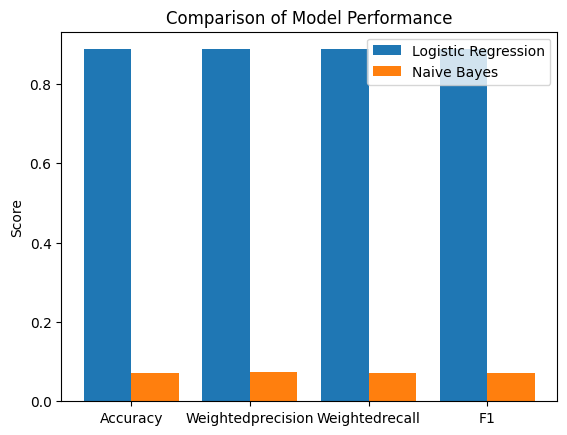

In [ ]:

# 7. Visualization
# ------------------------------
x = range(len(metrics))
plt.bar([i - 0.2 for i in x], lr_scores, width=0.4, label='Logistic Regression')
plt.bar([i + 0.2 for i in x], nb_scores, width=0.4, label='Naive Bayes')

plt.xticks(x, [m.capitalize() for m in metrics])
plt.ylabel('Score')
plt.title('Comparison of Model Performance')
plt.legend()
plt.show()
